In [28]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [29]:
data=pd.read_csv('/datalab/AIML/car_data.csv')
print('Car Data Loaded Succesfully')
data.head(10)

Car Data Loaded Succesfully


,Horsepower,Weight,Engine_Size,Price
0,130,3504,2.5,20000
1,165,3693,3.0,25000
2,150,3436,2.8,23000
3,140,3449,2.2,21000
4,198,4341,3.8,32000
5,220,4354,4.0,35000
6,215,4732,4.5,37000
7,225,4380,4.6,39000
8,190,3850,3.3,31000
9,170,3560,2.9,27000


In [35]:
X=data[['Horsepower','Weight', 'Engine_Size']]. values
y=data['Price']. values
X=tf. constant (X,dtype=tf.float32)
y=tf. constant (y,dtype=tf.float32)
# print('Feature Tensor Shape:', X. shape)
# print('Label Tensor Shape: ',y. shape)

In [41]:
tf.random.set_seed(42)
model=tf.keras.Sequential([
    tf.keras.layers.Dense(16,activation='relu'),
    tf.keras.layers.Dense(8,activation='relu'),
    tf.keras.layers.Dense(1)
    ])
model.compile(optimizer='adam',loss='mae',metrics=['mae'])
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [38]:
history=model.fit(X,y,epochs=200,verbose=0)

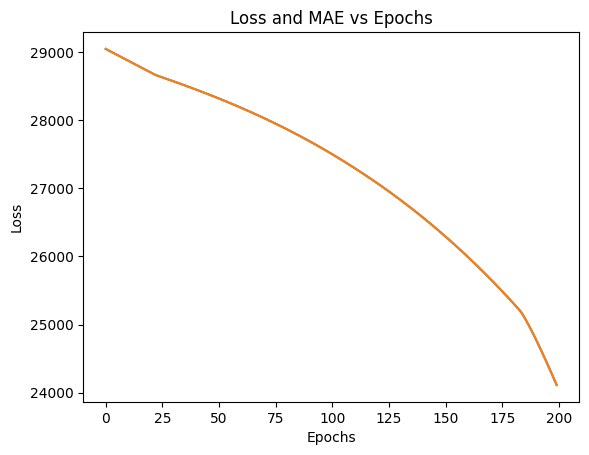

In [39]:
plt.plot(history.history['loss'],label='Loss')
plt.plot(history.history['mae'],label='MAE')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss and MAE vs Epochs')
plt.legend
plt.show()

In [40]:
test_sample=np.array([[160,3550,2.5]])
prediction=model.predict(test_sample)
print('prediction',prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
prediction 4480.6953
